[2026-04-15 11:06:32] [info     ] cn_stock_basic_selector.v7 开始运行 ..
[2026-04-15 11:06:32] [info     ] cn_stock_basic_selector.v7 命中缓存
[2026-04-15 11:06:32] [info     ] cn_stock_basic_selector.v7 运行完成 [0.038s].
基础股票池记录数: 179680
过滤后股票池记录数: 163692
  [pe_ttm_raw] 已缓存
  [smallcap80/pe_ttm] 已缓存
  [pb_raw] 已缓存
  [smallcap80/pb] 已缓存
  [ps_ttm_raw] 已缓存
  [smallcap80/ps_ttm] 已缓存
  [pcf_net_ttm_raw] 已缓存
  [smallcap80/pcf_ttm] 已缓存
  [roe_avg_ttm_raw] 已缓存
  [smallcap80/roe_ttm] 已缓存
  [roa_avg_ttm_raw] 已缓存
  [smallcap80/roa_ttm] 已缓存
  [dividend_yield_ratio_raw] 已缓存
  [smallcap80/dividend_yield] 已缓存
  [total_market_cap_raw] 已缓存
  [smallcap80/total_market_cap] 已缓存
  [float_market_cap_raw] 已缓存
  [smallcap80/float_market_cap] 已缓存
  [close_raw] 已缓存
  [smallcap80/close] 已缓存


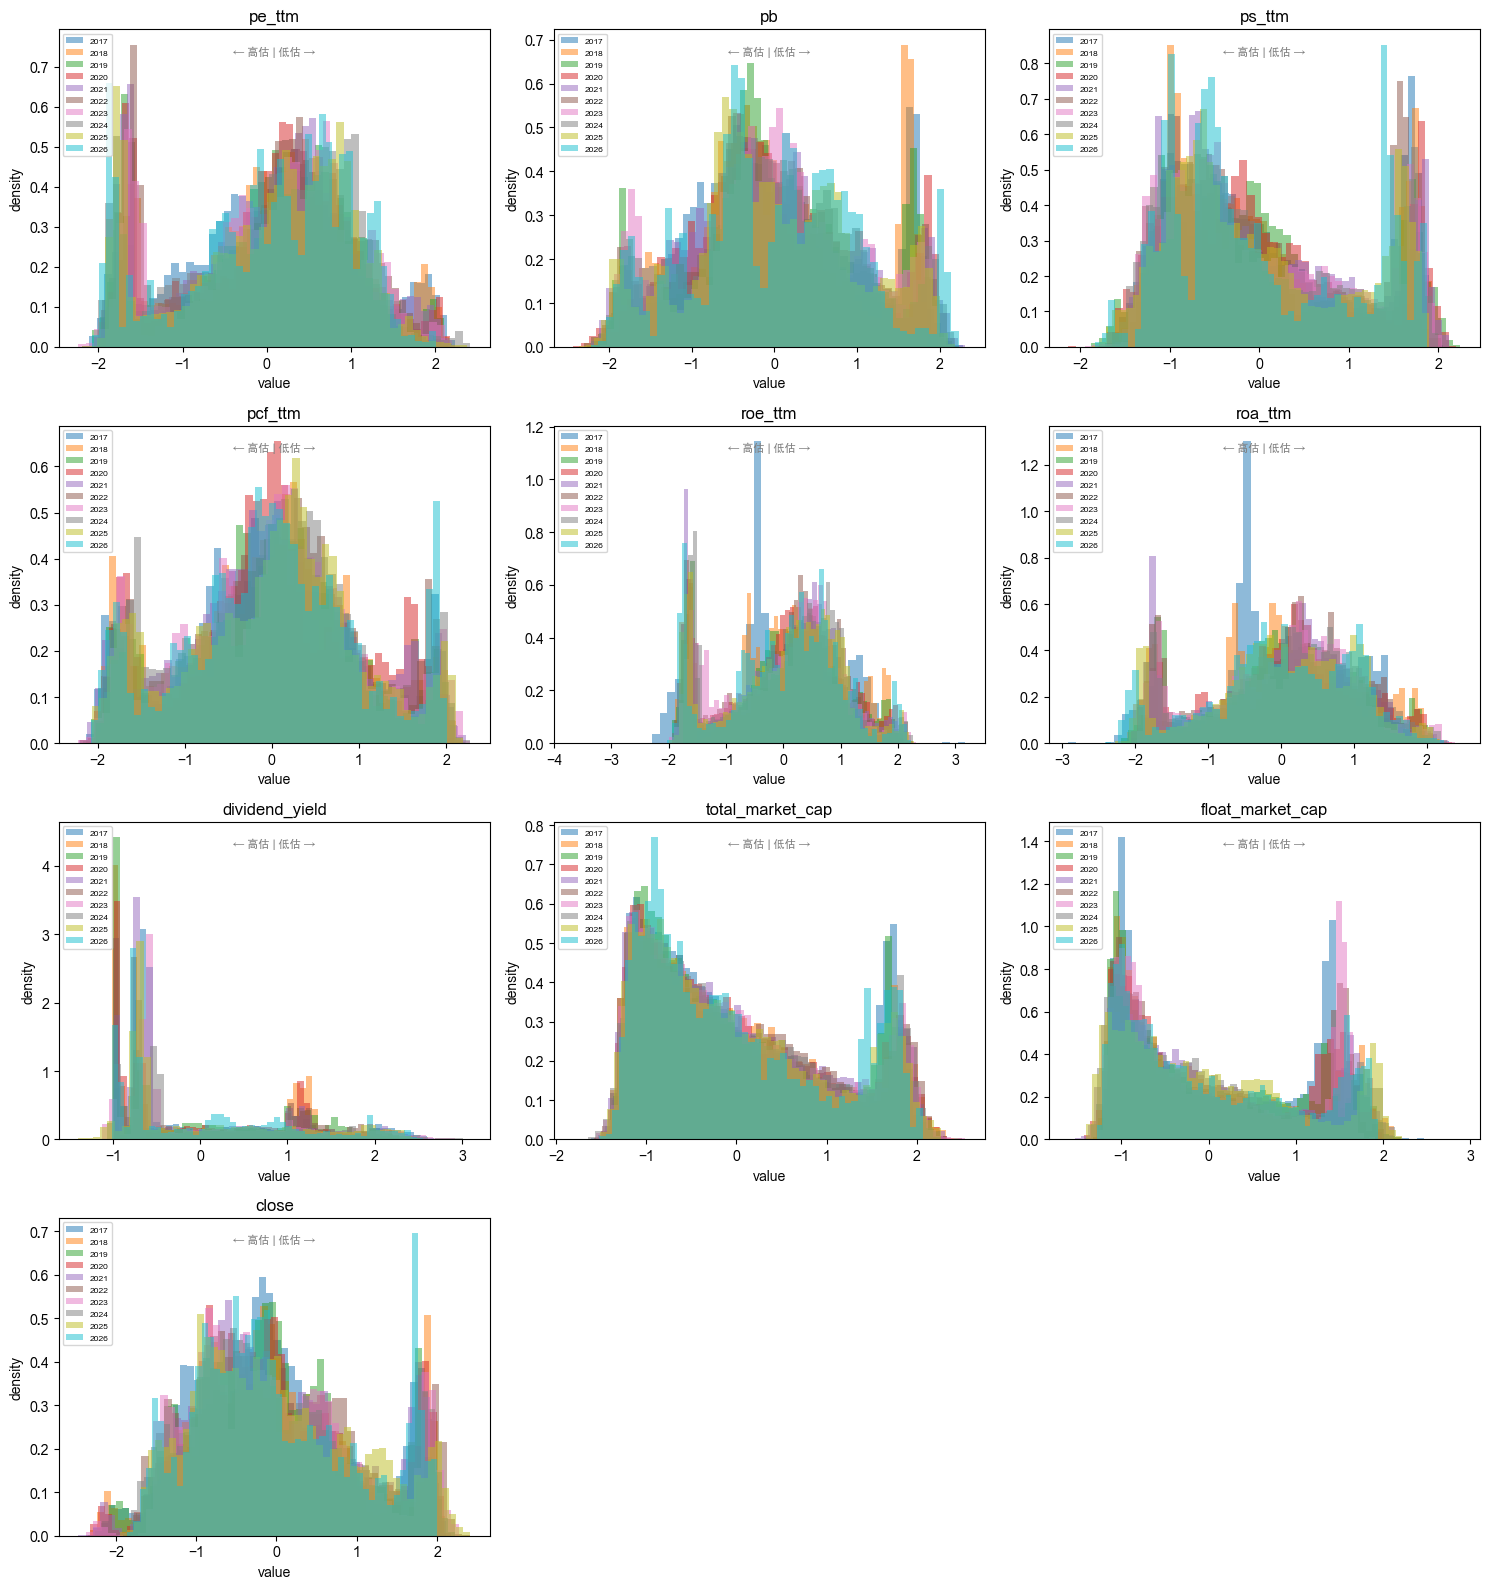

In [2]:
# 因子低估方向说明（所有因子处理后都是"值越大越好"，图上右边=低估/优选）
# ──────────────────────────────────────────────────────────────────────────
# 因子              处理方式          原始值含义            低估逻辑
# ──────────────────────────────────────────────────────────────────────────
# pe_ttm           inverse(取倒数)   PE越小越便宜           1/PE越大 → 右边低估
# pb               inverse           PB越小越便宜           1/PB越大 → 右边低估
# ps_ttm           inverse           PS越小越便宜           1/PS越大 → 右边低估
# pcf_ttm          inverse           PCF越小越便宜          1/PCF越大 → 右边低估
# roe_ttm          identity(不变)    ROE越大越好            直接z-score → 右边好
# roa_ttm          identity          ROA越大越好            直接z-score → 右边好
# dividend_yield   identity          股息率越高越好         直接z-score → 右边好
# total_market_cap inverse           市值越小越好(小盘溢价) 1/市值越大 → 右边小盘
# float_market_cap inverse           流通市值越小越好       1/流通市值越大 → 右边小盘
# close            inverse           股价越低越好(低价股)   1/股价越大 → 右边低价
# ──────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 120)
pd.set_option("display.precision", 2)

from factor import compute_pool_factors, FACTOR_NAMES
from filter import get_universe_pool, UNIVERSE_SIZE

START_DATE = "2017-01-01"
END_DATE = "2026-04-07"

pool_df = get_universe_pool(
    start_date=START_DATE,
    end_date=END_DATE,
    universe_size=UNIVERSE_SIZE,
)
factor_df = compute_pool_factors(
    pool_name=f"smallcap{UNIVERSE_SIZE}",
    pool_df=pool_df[["date", "instrument"]],
    start_date=START_DATE,
    end_date=END_DATE,
    factor_names=FACTOR_NAMES,
)
factor_df["year"] = factor_df["date"].dt.year

# for factor_name in FACTOR_NAMES:
#     print(f"\n{factor_name}\n{'-'*40}")
#     print(factor_df.groupby("year")[factor_name].describe())

n_factors = len(FACTOR_NAMES)
n_cols = 3
n_rows = (n_factors + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

years = sorted(factor_df["year"].unique())

for i, factor_name in enumerate(FACTOR_NAMES):
    ax = axes[i]
    for year in years:
        year_data = factor_df.loc[factor_df["year"] == year, factor_name].dropna()
        if len(year_data) < 100:
            continue
        ax.hist(year_data, bins=50, alpha=0.5, label=str(year), density=True)
    ax.set_title(factor_name)
    ax.set_xlabel("value")
    ax.set_ylabel("density")
    ax.legend(loc="upper left", fontsize=6)
    ax.annotate("← 高估 | 低估 →", xy=(0.5, 0.95), xycoords="axes fraction",
                ha="center", va="top", fontsize=8, color="gray")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
